In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
log_files = sorted(glob.glob('/home/zhaobc/scientist/submitit_logs_repeat/*.out'))

In [3]:
log_files

['/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_0_slurm_1114940.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_0_slurm_1116981.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_1_slurm_1114941.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_1_slurm_1116982.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_2_slurm_1114942.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_2_slurm_1116983.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_3_slurm_1114943.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_3_slurm_1116984.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_4_slurm_1114944.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_10_repeat_4_slurm_1116985.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_11_repeat_0_slurm_1114945.out',
 '/home/zhaobc/scientist/submitit_logs_repeat/record_11_repeat_0_

In [4]:
def parse_metrics(line):
    """Parse validation loss and train time from a log line, only when steps are finished"""
    # Example line: step:1395/1395 val_loss:3.2771 train_time:200367ms step_avg:144.67ms
    parts = line.split()
    
    # Check if steps are finished
    step_part = None
    for part in parts:
        if part.startswith('step:'):
            step_part = part.split(':')[1]
            current, total = map(int, step_part.split('/'))
            if current != total:  # Steps not finished
                return None, None
            break
    
    if not step_part:  # No step info found
        return None, None
            
    # Find val_loss
    val_loss = None
    for part in parts:
        if part.startswith('val_loss:'):
            val_loss = float(part.split(':')[1])
            
    # Find train_time 
    train_time = None
    for part in parts:
        if part.startswith('train_time:'):
            train_time = int(part.split(':')[1].rstrip('ms'))
            
    return val_loss, train_time


In [5]:
parse_metrics('step:139/1395 val_loss:3.2771 train_time:200367ms step_avg:144.67ms')

(None, None)

In [6]:
# Process log files and compute statistics
record_times = {}

for log_file in log_files:
    record_num = int(log_file.split('record_')[1].split('_')[0])
    if record_num not in record_times:
        record_times[record_num] = []
    
    with open(log_file, 'r') as f:
        for line in f:
            val_loss, train_time = parse_metrics(line)
            if train_time is not None:
                record_times[record_num].append(train_time)

# Compute and print statistics
print("Training Time Statistics:")
print("-" * 50)
mean_time = {}
std_time = {}
for record_num, times in sorted(record_times.items()):
    if times:
        mean_time[record_num] = np.mean(times)
        std_time[record_num] = np.std(times)
        print(f"Record {record_num}:")
        print(f"  Mean training time: {mean_time[record_num]:.2f} ms")
        print(f"  Std training time: {std_time[record_num]:.2f} ms")
        print(f"  Number of measurements: {len(times)}")
        print("-" * 50)

Training Time Statistics:
--------------------------------------------------
Record 4:
  Mean training time: 1256441.90 ms
  Std training time: 37980.47 ms
  Number of measurements: 10
--------------------------------------------------
Record 5:
  Mean training time: 1023673.50 ms
  Std training time: 7365.53 ms
  Number of measurements: 10
--------------------------------------------------
Record 6:
  Mean training time: 765592.80 ms
  Std training time: 5922.16 ms
  Number of measurements: 10
--------------------------------------------------
Record 7:
  Mean training time: 761336.50 ms
  Std training time: 3805.14 ms
  Number of measurements: 10
--------------------------------------------------
Record 8:
  Mean training time: 670114.10 ms
  Std training time: 9496.43 ms
  Number of measurements: 10
--------------------------------------------------
Record 9:
  Mean training time: 513359.70 ms
  Std training time: 15747.18 ms
  Number of measurements: 10
----------------------------

In [7]:
mean_time, std_time

({4: 1256441.9,
  5: 1023673.5,
  6: 765592.8,
  7: 761336.5,
  8: 670114.1,
  9: 513359.7,
  10: 481131.9,
  11: 447459.2,
  12: 311571.9,
  13: 288889.7,
  14: 274645.8,
  15: 240798.1,
  16: 239226.0,
  17: 218405.5,
  18: 209907.125,
  19: 200140.75,
  20: 189068.25,
  21: 184153.7},
 {4: 37980.47252062565,
  5: 7365.528334749653,
  6: 5922.1565632799675,
  7: 3805.1381643772147,
  8: 9496.433967021516,
  9: 15747.184129551544,
  10: 2315.289072664578,
  11: 3259.97364406524,
  12: 1220.1590429120295,
  13: 927.6096215542399,
  14: 6034.273126069121,
  15: 2337.853949672648,
  16: 6700.251811188393,
  17: 40.5,
  18: 1495.1822997129814,
  19: 600.6738056826961,
  20: 770.6353142051044,
  21: 593.6435041335835})

In [8]:
import matplotlib.ticker as ticker

In [9]:
# 4 1338000
# 5 912000
# 6 786000
# 7 720000
# 8 648000
# 9 492000
# 10 468000
# 11 432000
# 12 301800
# 13 279600
# 14 264600
# 15 237000
# 16 228000
# 17 214200
# 18 204000
# 19 188520
# 20 179520
# 21 175980
human_time = {
    4: 1338000,
    5: 912000,
    6: 786000,
    7: 720000,
    8: 648000,
    9: 492000,
    10: 468000,
    11: 432000,
    12: 301800,
    13: 279600,
    14: 264600,
    15: 237000,
    16: 228000,
    17: 214200,
    18: 204000,
    19: 188520,
    20: 179520,
    21: 175980,
}

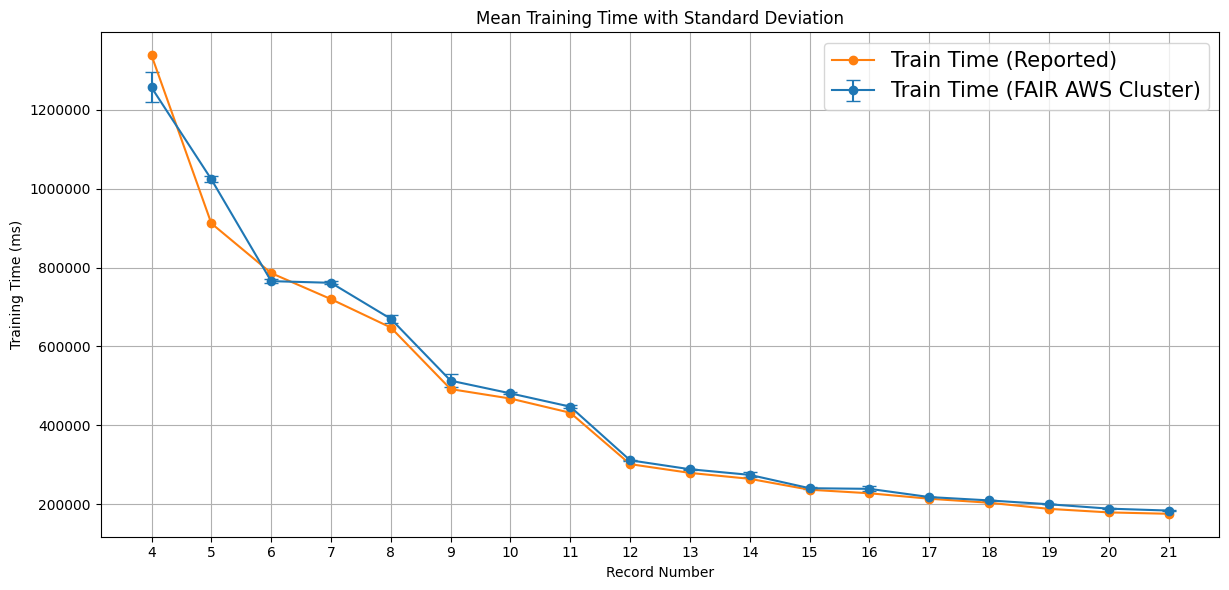

In [10]:
# Create a plot of mean training times with error bars
plt.figure(figsize=(12, 6))

# Convert record numbers to list for plotting
records = sorted(mean_time.keys())
means = [mean_time[r] for r in records]
stds = [std_time[r] for r in records]

reported_time = [human_time[r] for r in records]

# Create the plot with error bars
plt.errorbar(records, means, yerr=stds, fmt='o-', capsize=5, label='Train Time (FAIR AWS Cluster)')

plt.plot(records, reported_time, 'o-', label='Train Time (Reported)')

# Customize the plot
plt.xlabel('Record Number')
plt.ylabel('Training Time (ms)')
plt.title('Mean Training Time with Standard Deviation')
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(records)

# Adjust layout to prevent label cutoff
plt.tight_layout()
def plain_formatter(x, pos):
    return f"{x:.0f}"
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.legend(fontsize=15)
# Show the plot
plt.show()

In [11]:
stds

[37980.47252062565,
 7365.528334749653,
 5922.1565632799675,
 3805.1381643772147,
 9496.433967021516,
 15747.184129551544,
 2315.289072664578,
 3259.97364406524,
 1220.1590429120295,
 927.6096215542399,
 6034.273126069121,
 2337.853949672648,
 6700.251811188393,
 40.5,
 1495.1822997129814,
 600.6738056826961,
 770.6353142051044,
 593.6435041335835]